In [2]:
print('Hello world')

Hello world


#### 샘플 데이터 다운로드

In [2]:
import gdown

In [3]:
# Google Drive 파일 링크
url = 'https://drive.google.com/uc?id=1RsxG4LUD9cBUSYr24ca8agghGIdIoXFl'

# 파일 다운로드
gdown.download(url, output='data.zip', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1RsxG4LUD9cBUSYr24ca8agghGIdIoXFl
From (redirected): https://drive.google.com/uc?id=1RsxG4LUD9cBUSYr24ca8agghGIdIoXFl&confirm=t&uuid=e807cdb5-dbc1-4214-90ed-f3a6a9f27c6b
To: /content/data.zip
100%|██████████| 1.63G/1.63G [00:20<00:00, 80.7MB/s]


'data.zip'

In [4]:
import os
import zipfile

# 사용자에게 폴더 이름 입력받기
target_folder = input("어디다 압축 해제할 지 폴더명 입력하셈: ")

target_path = f'/content/{target_folder}'
os.makedirs(target_path, exist_ok=True)

# ✅ 1단계: 가장 바깥 data.zip 압축 해제
!unzip -q data.zip -d {target_path}

# ✅ 2단계: 하위 폴더까지 순회하면서 모든 zip 파일 재귀적으로 풀기
def unzip_all_in_dir(directory):
    for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith('.zip'):
                zip_path = os.path.join(root, file)

                print(f"📦 {zip_path} 압축 해제 중...")
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(root)

                # ✅ 압축 풀었으면 원본 zip 삭제하고 싶다면 주석 해제
                # os.remove(zip_path)

# 실행
unzip_all_in_dir(target_path)

print("🎉 모든 zip 및 하위 zip 파일 압축 해제 완료!")


어디다 압축 해제할 지 폴더명 입력하셈: data
📦 /content/data/wolnam_ssam.zip 압축 해제 중...
🎉 모든 zip 및 하위 zip 파일 압축 해제 완료!


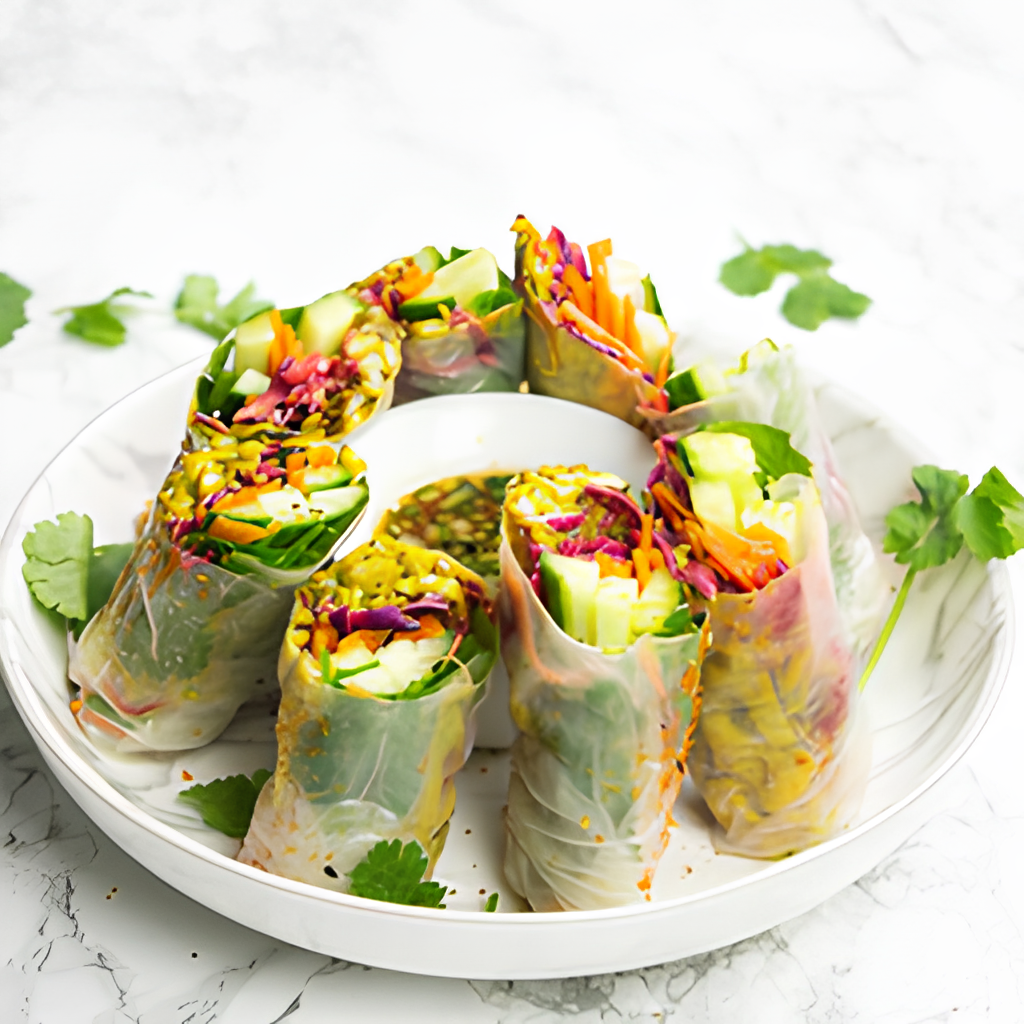

In [12]:
from PIL import Image
Image.open(f'{target_path}/wolnam_ssam/png/wolnam_ssam_1000.png')

In [14]:
import json
json_file = f'{target_path}/wolnam_ssam/json/1000_vietnam_wolnam_ssam.json'

with open(json_file, 'r', encoding='utf-8') as f:
  data = json.load(f)

json_string = json.dumps(data, indent=2, ensure_ascii=False)
print(json_string)


# json.load(f)	파일에서 JSON 읽기
# json.dumps() → Python 객체를 JSON 문자열로 다시 변환
# indent=2 → 예쁘게 들여쓰기
# ensure_ascii=False → 한글이 깨지지 않게 출력

{
  "instance_num": 1000,
  "country": "vietnam",
  "food_class": "wolnam_ssam",
  "ingredients": [
    {
      "subtype": "vegetable",
      "ingredient": "cilantro"
    },
    {
      "subtype": "soup_sauce_spice",
      "ingredient": "other_sauce_and_spices"
    },
    {
      "subtype": "grain_nuts",
      "ingredient": "rice_products"
    }
  ]
}
